In [16]:
# input
fasta_file = "../tmp/low_plddt_high_proba.fasta"
site_pred_file = "../tmp/low_plddt_high_proba.tsv"
# output
bg_file = "./fig/metaldb_ched_comp.pdf"
bg_prob_file = "./fig/metaldb_ched_prob_comp.pdf"
prob_plddt_file = "./fig/metaldb_ched_prob_plddt_comp.pdf"

In [17]:
from Bio import SeqIO
import pandas as pd

id2seq = dict()
for i in SeqIO.parse(fasta_file, "fasta"):
    id2seq[i.id.split("-")[1]] = str(i.seq)

df = pd.read_table(site_pred_file)

In [18]:
def get_resi_str(seq_id: str, site: str):
    posis = [int(i) for i in site.split(",")]
    seq = id2seq[seq_id]
    return ",".join([seq[p] for p in posis])

df['resi'] = df.apply(lambda row: get_resi_str(row['seq_id'], row['site']), axis=1)

In [19]:
ched_cnt = dict(zip(["C", "H", "E", "D"], [0 for _ in range(4)]))
for _, row in df.iterrows():
    for k in ched_cnt.keys():
        ched_cnt[k] += row['resi'].count(k)
ched_cnt

{'C': 331012, 'H': 30422, 'E': 1610, 'D': 6895}

In [20]:
total = sum(ched_cnt.values())
cur_proportions = {resi: s / total for resi, s in ched_cnt.items()}
# from "../../aa_comp/calc.ipynb"
metaldb_bg_proportions = {
    "C": 0.426816,
    "H": 0.253894,
    "E": 0.099337,
    "D": 0.219953,
}

metaldb_prob_08_bg_proportions = {
    "C": 0.517889,
    "H": 0.248057,
    "E": 0.063446,
    "D": 0.170607,
    }

x = ["C", "H", "E", "D"]
y_cur = [cur_proportions[i] for i in x]
y_bg = [metaldb_bg_proportions[i] for i in x]
y_bg_prob = [metaldb_prob_08_bg_proportions[i] for i in x]

In [21]:
def draw_pie(
    y,
    file
):
    import matplotlib.pyplot as plt
    import numpy as np
    
    plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
    plt.figure(figsize=(2.4, 2.4))

    plt.pie(
        y,
        colors=['#EAD98F', '#6797C4', '#C99EBD', '#AF98BE'],
        autopct="%.1f%%",
    )
    plt.legend(
        x, 
        bbox_to_anchor=(-0.1, 0.5), 
        loc='center right', 
    )
    plt.savefig(file, bbox_inches="tight", transparent=True)

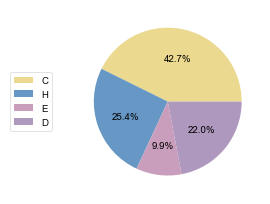

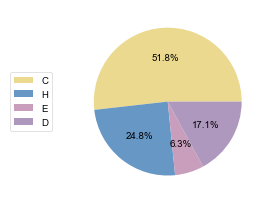

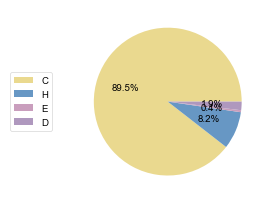

In [22]:
draw_pie(y_bg, bg_file)
draw_pie(y_bg_prob, bg_prob_file)
draw_pie(y_cur, prob_plddt_file)